In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [24]:
x = pd.read_table('x.txt',header=None,names=['x'])
N = 200
T_min, T_max = 1,1000
T = np.array([T_min * np.exp(np.log(T_max/T_min)*i/(N-1)) for i in range(N)])

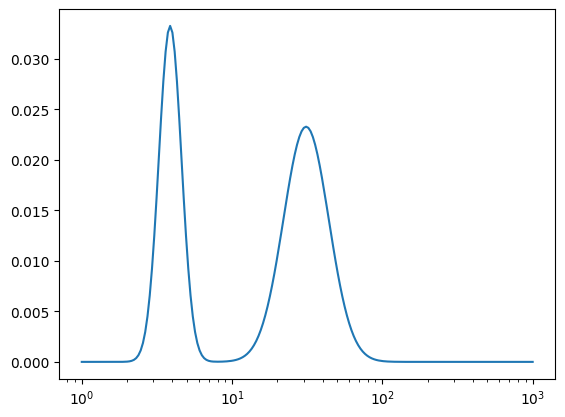

In [25]:
plt.plot(T,x)
plt.xscale('log')

In [26]:
M = 50
tmin, tmax = 0,1.5
t = np.array([tmin + (tmax - tmin)*i/(M-1) for i in range(M)])
K = np.exp(-np.outer(t,T))

In [27]:
z = K@x.x
sigma = 0.01 * z[0]
w = np.random.normal(loc=np.zeros(M), scale=sigma,size=(M,))
y = z + w

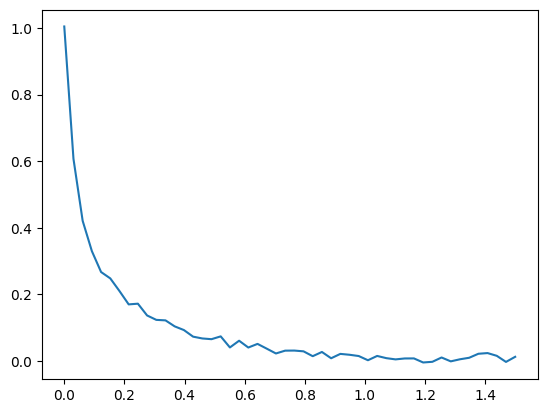

In [28]:
plt.plot(t, y)

In [29]:
def f(x):
    return 0.5 * np.linalg.norm(K@x - y)**2
def error(target, estimate):
    return np.linalg.norm(target - estimate)**2/np.linalg.norm(target)**2

def test_method_beta(method, beta_values):
    errors = []
    for beta in beta_values:
        x_beta = method(K, y, beta)
        errors.append(error(x.x, x_beta))
    return errors

Methode simple : inverse de matrice

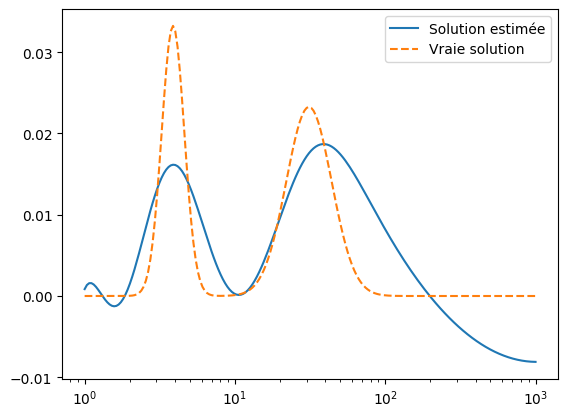

In [30]:
D = np.identity(N,dtype=float)
for i in range(1,N):
    D[i,i-1] = -1.0
def g(x):
    return 0.5 * np.linalg.norm(D@x)**2

#cas convex simple
def solve_min(K, D, y, beta):
    A = K.T @ K + beta * (D.T @ D)
    b = K.T @ y
    return np.linalg.solve(A, b)

# betas = np.linspace(0.01, 1, 9)
# min_error = float('inf')
# best_beta,best_x = None, None
# quadratic_errors = []
# for beta in betas:
#     solved_x = solve_min(K, D, y, beta)
#     quadratic_error = error(solved_x, x.x)
#     if quadratic_error < min_error:
#         min_error = quadratic_error
#         best_beta = beta
#         best_x = solved_x
#     quadratic_errors.append(quadratic_error)
best_x = solve_min(K, D, y, 1.0)
# plt.figure()
# plt.plot(betas, quadratic_errors)
plt.figure()
plt.plot(T, best_x)
plt.plot(T, x.x, linestyle='dashed')
plt.xscale('log')
plt.legend(['Solution estimée', 'Vraie solution'])
# plt.title(f'Solution estimée avec beta optimal = {best_beta}')
quadratic_error = error(best_x, x.x)
# print(f"Erreur entre la solution estimée et la vraie solution : {quadratic_error} avec beta = {best_beta}")

methode avec une descente de gradient

In [79]:
def f(x, K, D, y, beta):
    return 0.5*np.linalg.norm(K@x - y)**2 + 0.5*beta*np.linalg.norm(D@x)**2

def grad_f(x, K, D, y, beta):
    return K.T@(K@x - y) + beta*D.T@(D@x)

def gradient_descent(K, D, y, beta, x0=None, max_iter=10000, tol=1e-6):
    if x0 is None:
        x0 = np.zeros(K.shape[1])
    x = x0
    lr = (2/np.linalg.norm(K.T@K + beta * D.T@D,2))/2 #step size assuring cvg
    for i in range(max_iter):
        grad = grad_f(x, K, D, y, beta)
        x_new = x - lr * grad
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x


In [72]:
np.linalg.norm(D.T@D)

np.float64(34.56877203488721)

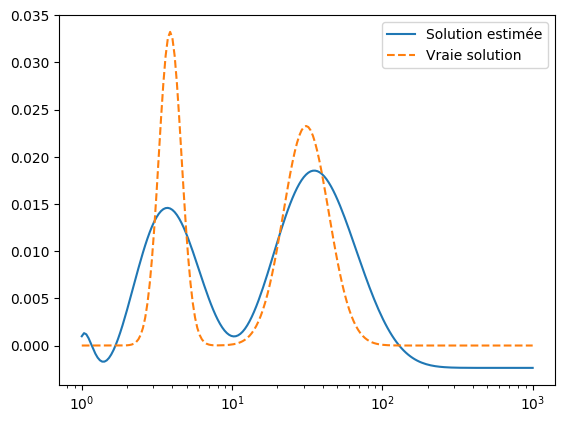

In [80]:
x_solved = gradient_descent(K, D, y, 0.7)
plt.figure()
plt.plot(T, x_solved)
plt.plot(T, x.x, linestyle='dashed')
plt.xscale('log')
plt.legend(['Solution estimée', 'Vraie solution'])

descente de gradient optimisée avec scipy

Erreur entre la solution estimée et la vraie solution : 0.19942755627840775 avec beta = 0.12


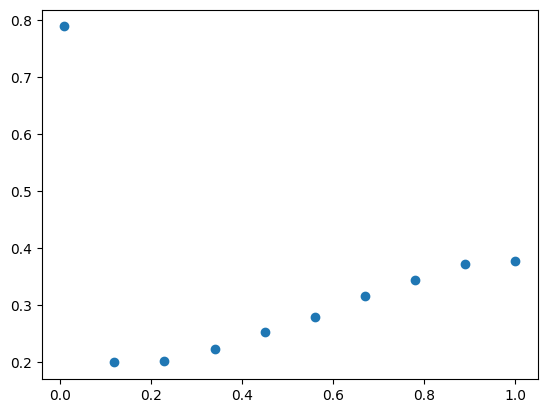

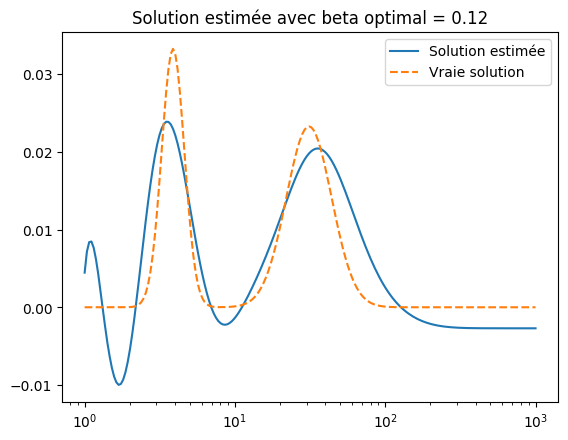

In [69]:
betas = np.linspace(0.01,1 , 10)
min_error = float('inf')
best_beta,best_x = None, None
quadratic_errors = []
for beta in betas:
    solved_x = minimize(
    fun=lambda x: f(x, K, D, y, beta),
    x0=np.zeros(K.shape[1]),
    jac=lambda x: grad_f(x, K, D, y, beta),
    method="CG"
).x
    quadratic_error = error(solved_x, x.x)
    if quadratic_error < min_error:
        min_error = quadratic_error
        best_beta = beta
        best_x = solved_x
    quadratic_errors.append(quadratic_error)
plt.figure()
plt.scatter(betas, quadratic_errors)
plt.figure()
plt.plot(T, best_x)
plt.plot(T, x.x, linestyle='dashed')
plt.xscale('log')
plt.legend(['Solution estimée', 'Vraie solution'])
plt.title(f'Solution estimée avec beta optimal = {best_beta}')
quadratic_error = error(best_x, x.x)
print(f"Erreur entre la solution estimée et la vraie solution : {quadratic_error} avec beta = {best_beta}")

In [34]:
import proxop

In [35]:
solved_x.shape

(200,)